# 00 KPI Engineering
Create all required KPIs, bins, quality checks, summaries, and exports.

In [ ]:
import warnings
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore")
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "utils" / "utils.py").exists():
    if (PROJECT_ROOT / "notebooks" / "utils" / "utils.py").exists():
        PROJECT_ROOT = PROJECT_ROOT / "notebooks"
    elif (PROJECT_ROOT.parent / "utils" / "utils.py").exists():
        PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from utils.utils import ensure_project_dirs, load_raw_dataset, clean_dataset, PROCESSED_DIR, REPORTS_DIR, FIGURES_DIR
from utils.features import engineer_kpis, build_post_feature_sets, aggregate_business_features
from utils.evaluation import regression_metrics, rank_models
from utils.visualization import set_plot_style, save_figure

set_plot_style()
ensure_project_dirs()
RAW_DATA_PATH = Path("../jsons/all_final_appended.json")

if not RAW_DATA_PATH.exists():
    RAW_DATA_PATH = PROJECT_ROOT / "synthetic_generator" / "synthetic_social_media_posts.csv"
KPI_PATH = PROCESSED_DIR / "kpi_dataset.csv"

## Load and Clean Data

In [10]:
def load_raw_dataset(path):
    data_path = Path(path)

    if not data_path.exists():
        raise FileNotFoundError(f"Dataset not found at {data_path}")

    if data_path.suffix.lower() == ".csv":
        return pd.read_csv(data_path)

    if data_path.suffix.lower() == ".json":
        return pd.read_json(data_path)

    raise ValueError(f"Unsupported file type: {data_path.suffix}")


raw_df = load_raw_dataset(RAW_DATA_PATH)
clean_df = clean_dataset(raw_df)

print("Raw:", raw_df.shape, "Clean:", clean_df.shape)

display(clean_df.head())

Raw: (710, 25) Clean: (656, 25)


,business_name,sector,followers_count,post_date,posting_hour,day_of_week,month,post_type,caption_text,caption_length,...,language,CTA_present,promo_post,discount_percent,mentions_location,religious_theme,patriotic_theme,arabic_dialect_style,sponsored,kind
0,LOFT Palestine,Fashion,4392.0,2026-03-31,0.0,Tuesday,3.0,reel,إطلالة أنثوية بلمسة عصرية ✨ من LOFT. للطلب الت...,88,...,Arabic,True,False,0.0,True,False,False,True,0.0,NaN
1,LOFT Palestine,Fashion,4392.0,2026-03-18,0.0,Wednesday,3.0,reel,اختيارك المثالي لإطلالة كاجول مميزة 🤍✨ LOFT كو...,111,...,Arabic,True,False,0.0,True,False,False,True,0.0,NaN
2,LOFT Palestine,Fashion,4392.0,2026-03-16,0.0,Monday,3.0,reel,ستايل شبابي بلمسة عصرية له ولها ✨ اختيارات ممي...,133,...,Arabic,True,False,0.0,True,False,False,True,0.0,NaN
3,LOFT Palestine,Fashion,4392.0,2026-03-07,0.0,Saturday,3.0,reel,ستايل يناسبك، وتجربة تستحق الزيارة ✨ زورونا في...,82,...,Arabic,True,False,0.0,True,False,False,True,0.0,NaN
4,LOFT Palestine,Fashion,4392.0,2026-03-05,0.0,Thursday,3.0,reel,#LOFTSTYLE #Menstyle,21,...,English,False,False,0.0,False,False,False,False,0.0,NaN


## Engineer KPIs and Validate Division Safety

In [11]:
df = engineer_kpis(clean_df)
df["post_date"] = pd.to_datetime(
    df["post_date"],
    errors="coerce"
)
rate_cols = ["engagement_rate", "like_rate", "comment_rate", "view_rate", "view_engagement_rate"]
invalid = {c: int(np.isinf(df[c]).sum() + df[c].isna().sum()) for c in rate_cols}
print("Invalid rate values:", invalid)
print("followers_count==0:", int((df["followers_count"] == 0).sum()))
print("views_count==0:", int((df["views_count"] == 0).sum()))
# Weekly KPI
df["week"] = (
    df["post_date"]
    .dt.to_period("W")
    .astype(str)
)
display(df.head())

Invalid rate values: {'engagement_rate': 0, 'like_rate': 0, 'comment_rate': 0, 'view_rate': 0, 'view_engagement_rate': 0}
followers_count==0: 0
views_count==0: 193


,business_name,sector,followers_count,post_date,posting_hour,day_of_week,month,post_type,caption_text,caption_length,...,is_reel,posting_time_bin,caption_length_bin,hashtags_count_bin,emoji_count_bin,engagement_level,business_size_bin,high_engagement,high_view_rate,high_comment_rate
0,LOFT Palestine,Fashion,4392.0,2026-03-31,0.0,Tuesday,3,reel,إطلالة أنثوية بلمسة عصرية ✨ من LOFT. للطلب الت...,88,...,1,night,medium,none,few,medium,small,0,0,0
1,LOFT Palestine,Fashion,4392.0,2026-03-18,0.0,Wednesday,3,reel,اختيارك المثالي لإطلالة كاجول مميزة 🤍✨ LOFT كو...,111,...,1,night,medium,none,few,high,small,1,1,0
2,LOFT Palestine,Fashion,4392.0,2026-03-16,0.0,Monday,3,reel,ستايل شبابي بلمسة عصرية له ولها ✨ اختيارات ممي...,133,...,1,night,medium,none,few,high,small,1,1,1
3,LOFT Palestine,Fashion,4392.0,2026-03-07,0.0,Saturday,3,reel,ستايل يناسبك، وتجربة تستحق الزيارة ✨ زورونا في...,82,...,1,night,medium,none,few,high,small,1,1,0
4,LOFT Palestine,Fashion,4392.0,2026-03-05,0.0,Thursday,3,reel,#LOFTSTYLE #Menstyle,21,...,1,night,short,few,none,high,small,1,1,0


## Summary Tables and Exports

,sector,posts_count,engagement_mean,engagement_rate_mean,view_rate_mean,comment_rate_mean
4,Supermarkets,51,427.803922,0.175656,9.170855,0.002852
3,Influencers,80,68138.137500,0.012683,0.410743,0.000311
2,Gym,39,123.717949,0.010605,1.430251,0.000066
0,Cafes/Restaurants,228,258.157895,0.007876,8.909401,0.000299
1,Fashion,258,43.027132,0.003118,2.699511,0.000204


,business_name,sector,posts_count,engagement_mean,engagement_rate_mean,view_rate_mean,comment_rate_mean
11,Family Market PS,Supermarkets,16,1292.312500,0.547126,28.157070,0.008256
40,Nour Alsaqa,Influencers,2,87075.000000,0.079159,1.306364,0.001705
47,Robian Restaurant,Cafes/Restaurants,20,236.300000,0.036354,93.269231,0.000523
10,FPAIspal,Influencers,1,33281.000000,0.030255,0.000000,0.000983
2,Abu shukri restaurant-مطعم حمص ابو شكري,Cafes/Restaurants,3,71.666667,0.024713,0.000000,0.005172
59,aburob,Influencers,31,118166.129032,0.020731,0.807289,0.000538
57,Xtreme Fitness Ramallah,Gym,8,85.000000,0.018973,3.068359,0.000028
29,LOFT Palestine,Fashion,8,81.375000,0.018528,63.778603,0.000171
34,Mazaj Oriental - مزاج الشرقي,Cafes/Restaurants,16,340.437500,0.014931,0.542719,0.000159
20,Hamdan ElDahdouh,Influencers,2,15407.000000,0.014006,0.086818,0.000491


,post_type,posts_count,engagement_mean,engagement_rate_mean,view_rate_mean,comment_rate_mean
3,reel,463,11892.861771,0.025224,2.884112,0.000504
0,Image,95,161.294737,0.007435,4.910931,0.000379
1,Reel,84,298.845238,0.006175,17.646288,0.000082
2,post,14,59.571429,0.005919,0.000000,0.001262


,week,posts_count,engagement_mean,engagement_rate_mean,view_rate_mean,comment_rate_mean
42,2024-09-30/2024-10-06,2,891.500000,0.137154,0.000000,0.002000
100,2026-04-13/2026-04-19,26,1147.961538,0.100896,4.516595,0.001559
27,2023-06-26/2023-07-02,1,1866.000000,0.081842,2.675439,0.000351
101,2026-04-20/2026-04-26,32,2431.437500,0.080123,3.628070,0.000714
48,2024-12-16/2024-12-22,2,3293.500000,0.073880,0.060455,0.000588
50,2024-12-30/2025-01-05,2,71460.000000,0.065078,1.045455,0.001349
44,2024-11-18/2024-11-24,2,403.500000,0.062077,234.000000,0.000385
30,2023-08-14/2023-08-20,1,2354.000000,0.039299,1.803005,0.000117
99,2026-04-06/2026-04-12,25,303.160000,0.034345,5.080292,0.001674
7,2022-05-02/2022-05-08,1,90.000000,0.031034,0.000000,0.008621


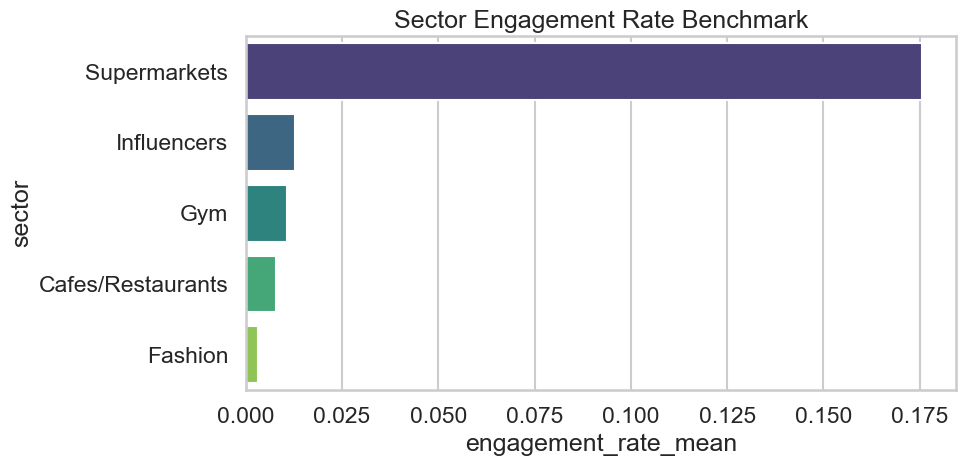

Insight: Top sector is Supermarkets with engagement rate 0.1757.


In [12]:
if "week" not in df.columns:
    df["post_date"] = pd.to_datetime(df["post_date"], errors="coerce")
    df["week"] = df["post_date"].dt.to_period("W").astype(str)
summaries = {}
for key, grp in {
    "sector": ["sector"],
    "business": ["business_name", "sector"],
    "post_type": ["post_type"],
    "week": ["week"],
    
}.items():
    summaries[key] = df.groupby(grp, as_index=False).agg(
        posts_count=("business_name", "size"),
        engagement_mean=("engagement", "mean"),
        engagement_rate_mean=("engagement_rate", "mean"),
        view_rate_mean=("view_rate", "mean"),
        comment_rate_mean=("comment_rate", "mean"),
    ).sort_values("engagement_rate_mean", ascending=False)
    display(summaries[key].head(10))

df.to_csv(PROCESSED_DIR / "kpi_dataset.csv", index=False)
for k, v in summaries.items():
    v.to_csv(REPORTS_DIR / f"kpi_summary_{k}.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 5))
plot_df = summaries["sector"].head(15)
sns.barplot(data=plot_df, x="engagement_rate_mean", y="sector", ax=ax, palette="viridis")
ax.set_title("Sector Engagement Rate Benchmark")
save_figure(fig, FIGURES_DIR, "kpi_sector_engagement_rate.png")
plt.show()

top_sector = summaries["sector"].iloc[0]
print(f"Insight: Top sector is {top_sector['sector']} with engagement rate {top_sector['engagement_rate_mean']:.4f}.")